# 第 1 节课 · 深度学习初见（动手版）

> 本 Notebook 是「深度学习实战培训」第一节课的动手演示材料，也可作为课后自学资料上传到代码仓库。

## 学习目标

通过 4 个可运行的 Demo，建立对深度学习几个核心方向的**直觉**：

| Demo | 方向 | 对应课程路线 | 核心直觉 |
|------|------|--------------|----------|
| MNIST 快速训练 | CV 基础 | L3 深度学习核心 | 模型通过 loss 下降、acc 上升来学习 |
| YOLOv8 目标检测 | CV 应用 | L4 计算机视觉 | 一次前向传播同时完成定位与分类 |
| GPT-2 文本生成 | NLP/LLM | L5 自然语言处理 | 自回归地"猜下一个词" |
| CLIP 零样本分类 | 多模态 | L6 多模态 | 图文在同一语义空间中比较相似度 |

## 如何使用

1. 确保已安装环境并运行通过 `check_env.py`。
2. 按顺序运行每个 Cell（`Shift + Enter`）。
3. 每个 Demo 都有**详细的打印输出和可视化**，帮助你理解中间过程。
4. 首次运行会自动下载数据集和预训练模型，请保持网络畅通。


## 0. 环境准备与全局设置

运行本 Notebook 需要：
- Python 3.9 - 3.11
- PyTorch（CPU/CUDA/MPS 均可）
- torchvision、transformers、ultralytics、PIL、matplotlib

> 如果本地没有 GPU，Demo 仍然可以运行，只是速度会慢一些。所有 Demo 都已在 CPU 上测试通过。


In [2]:
# 全局设置：自动选择设备、配置可视化字体
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import matplotlib.pyplot as plt

# 自动选择可用设备：CUDA > MPS(苹果) > CPU
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"✓ 当前使用设备: {device}")
if torch.cuda.is_available():
    print(f"  GPU 型号: {torch.cuda.get_device_name(0)}")
    print(f"  可用显存: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# 配置 matplotlib：尝试使用系统中文字体，避免中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

# 创建输出目录
os.makedirs("./outputs", exist_ok=True)
os.makedirs("./data/sample_images", exist_ok=True)
print("✓ 输出目录 ./outputs 已就绪")
print("✓ 示例图片目录 ./data/sample_images 已就绪")

✓ 当前使用设备: cuda
  GPU 型号: NVIDIA GeForce RTX 5070 Ti
  可用显存: 17.1 GB
✓ 输出目录 ./outputs 已就绪
✓ 示例图片目录 ./data/sample_images 已就绪


## 1. Demo 1：MNIST 手写数字快速训练

### 一句话直觉
给神经网络看大量手写数字图片，告诉它"这是 0、那是 1"，让它学会把图片映射到 0-9 这 10 个类别。

### 对应课程路线
**L3 深度学习核心**：CNN、反向传播、优化器、损失函数。

### 本 Demo 会展示什么
1. **数据长什么样**：随机抽取一些 MNIST 样本可视化。
2. **模型长什么样**：打印网络结构、计算参数量。
3. **训练过程**：每个 epoch 的 loss 和 accuracy 变化。
4. **训练曲线可视化**：画出 loss/acc 随 epoch 变化曲线。
5. **错误案例分析**：模型在哪些样本上犯了错。

### 观察重点
- `loss` 是否在下降：说明模型正在学习。
- `accuracy` 是否在上升：说明模型预测越来越准。
- 2 个 epoch 后测试准确率能否达到 95% 以上：说明 CNN 对这个简单任务很高效。

In [2]:
# 1.1 加载 MNIST 数据集
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 数据预处理：转成 Tensor，并按 MNIST 的全局均值/方差做标准化
# 标准化让数据分布更稳定，是训练神经网络的常见操作
transform = transforms.Compose([
    transforms.ToTensor(),                       # 像素值从 [0,255] 缩放到 [0,1]
    transforms.Normalize((0.1307,), (0.3081,))   # MNIST 全局均值和标准差
])

print("[1/6] 正在加载 MNIST 数据集（首次会自动下载，约 10MB）...")
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print(f"  训练集样本数: {len(train_dataset):,}")
print(f"  测试集样本数: {len(test_dataset):,}")
print(f"  单张图片尺寸: {train_dataset[0][0].shape}")  # (1, 28, 28)：1 通道，28x28 像素
print(f"  类别数: {len(train_dataset.classes)}，类别标签: {train_dataset.classes}")

# 用 DataLoader 把数据组织成 batch
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)
print(f"  训练 batch 数: {len(train_loader)}，每个 batch 128 张图")

[1/6] 正在加载 MNIST 数据集（首次会自动下载，约 10MB）...


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.89MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 141kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]

  训练集样本数: 60,000
  测试集样本数: 10,000
  单张图片尺寸: torch.Size([1, 28, 28])
  类别数: 10，类别标签: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
  训练 batch 数: 469，每个 batch 128 张图


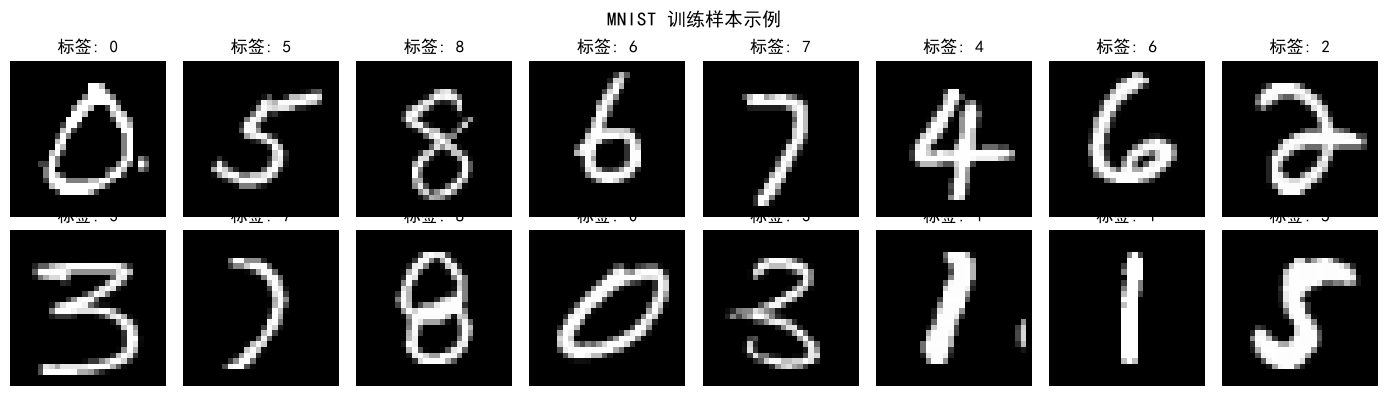

[保存] 样本可视化图 -> ./outputs/mnist_samples.png


In [3]:
# 1.2 可视化部分训练样本
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle("MNIST 训练样本示例", fontsize=14)

# 随机抽取 16 张图
indices = np.random.choice(len(train_dataset), 16, replace=False)
for ax, idx in zip(axes.flat, indices):
    img, label = train_dataset[idx]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"标签: {label}")
    ax.axis('off')

plt.tight_layout()
plt.savefig("./outputs/mnist_samples.png", dpi=120, bbox_inches='tight')
plt.show()
print("[保存] 样本可视化图 -> ./outputs/mnist_samples.png")

In [4]:
# 1.3 定义一个简单的 CNN 模型
class SimpleCNN(nn.Module):
    '''
    极简 CNN 结构:
    - 输入: (B, 1, 28, 28)  批次 x 通道 x 高 x 宽
    - Conv1: 1 -> 16 通道，28x28 -> 14x14（MaxPool 减半）
    - Conv2: 16 -> 32 通道，14x14 -> 7x7（MaxPool 减半）
    - Flatten + FC: 32*7*7 -> 64 -> 10
    '''
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x


model = SimpleCNN().to(device)

# 打印模型结构和参数量
print("[2/6] 模型结构:")
print(model)
print("\n模型参数量统计:")
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  总参数量: {total_params:,}")
print(f"  可训练参数量: {trainable_params:,}")

# 测试一下输入输出形状
sample_input = torch.randn(2, 1, 28, 28).to(device)
sample_output = model(sample_input)
print(f"\n输入形状: {sample_input.shape}")
print(f"输出形状: {sample_output.shape}  （2 个样本，每个 10 维 logits）")

[2/6] 模型结构:
SimpleCNN(
  (conv): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)

模型参数量统计:
  总参数量: 105,866
  可训练参数量: 105,866

输入形状: torch.Size([2, 1, 28, 28])
输出形状: torch.Size([2, 10])  （2 个样本，每个 10 维 logits）


In [8]:
# 1.4 训练模型并记录中间指标
import time

criterion = nn.CrossEntropyLoss()           # 分类任务常用损失：交叉熵
optimizer = optim.Adam(model.parameters(), lr=1e-3)  # Adam 优化器，学习率 0.001

num_epochs = 5
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

print("[3/6] 开始训练...")
start_time = time.time()

for epoch in range(1, num_epochs + 1):
    # ----- 训练阶段 -----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()       # 清空上一轮的梯度
        output = model(data)        # 前向传播
        loss = criterion(output, target)  # 计算损失
        loss.backward()             # 反向传播计算梯度
        optimizer.step()            # 根据梯度更新参数

        running_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += target.size(0)

        # 每 100 个 batch 打印一次中间状态，方便观察训练动态
        if (batch_idx + 1) % 100 == 0 or batch_idx == len(train_loader) - 1:
            avg_loss = running_loss / (batch_idx + 1)
            acc = 100.0 * correct / total
            print(f"  Epoch {epoch} | Batch {batch_idx+1:3d}/{len(train_loader)} | "
                  f"loss={avg_loss:.4f} | acc={acc:.2f}%")

    train_loss = running_loss / len(train_loader)
    train_acc = 100.0 * correct / total
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    # ----- 测试阶段 -----
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    with torch.no_grad():  # 测试时不计算梯度，节省显存/内存
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1)
            test_correct += pred.eq(target).sum().item()
            test_total += target.size(0)

    test_loss /= len(test_loader)
    test_acc = 100.0 * test_correct / test_total
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"  >> Epoch {epoch} 结束: train_loss={train_loss:.4f}, train_acc={train_acc:.2f}%, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.2f}%\n")

elapsed = time.time() - start_time
print(f"[完成] 训练结束，总耗时: {elapsed:.1f} 秒")

# 保存模型权重
save_path = "./outputs/mnist_cnn.pt"
torch.save(model.state_dict(), save_path)
print(f"[保存] 模型权重 -> {save_path}")

[3/6] 开始训练...
  Epoch 1 | Batch 100/469 | loss=0.0570 | acc=98.27%
  Epoch 1 | Batch 200/469 | loss=0.0515 | acc=98.39%
  Epoch 1 | Batch 300/469 | loss=0.0503 | acc=98.42%
  Epoch 1 | Batch 400/469 | loss=0.0504 | acc=98.43%
  Epoch 1 | Batch 469/469 | loss=0.0488 | acc=98.48%
  >> Epoch 1 结束: train_loss=0.0488, train_acc=98.48%, test_loss=0.0499, test_acc=98.30%

  Epoch 2 | Batch 100/469 | loss=0.0381 | acc=98.84%
  Epoch 2 | Batch 200/469 | loss=0.0382 | acc=98.81%
  Epoch 2 | Batch 300/469 | loss=0.0372 | acc=98.85%
  Epoch 2 | Batch 400/469 | loss=0.0369 | acc=98.88%
  Epoch 2 | Batch 469/469 | loss=0.0360 | acc=98.90%
  >> Epoch 2 结束: train_loss=0.0360, train_acc=98.90%, test_loss=0.0438, test_acc=98.64%

  Epoch 3 | Batch 100/469 | loss=0.0252 | acc=99.16%
  Epoch 3 | Batch 200/469 | loss=0.0266 | acc=99.11%
  Epoch 3 | Batch 300/469 | loss=0.0258 | acc=99.15%
  Epoch 3 | Batch 400/469 | loss=0.0265 | acc=99.14%
  Epoch 3 | Batch 469/469 | loss=0.0271 | acc=99.14%
  >> Epoch 3 

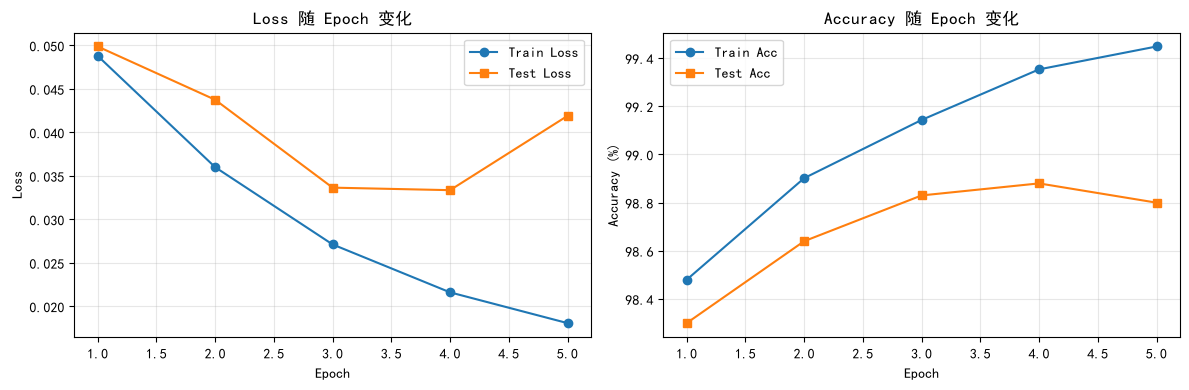

[保存] 训练曲线 -> ./outputs/mnist_training_curves.png


In [9]:
# 1.5 可视化训练曲线
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss 曲线
axes[0].plot(range(1, num_epochs + 1), history["train_loss"], marker='o', label='Train Loss')
axes[0].plot(range(1, num_epochs + 1), history["test_loss"], marker='s', label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss 随 Epoch 变化')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy 曲线
axes[1].plot(range(1, num_epochs + 1), history["train_acc"], marker='o', label='Train Acc')
axes[1].plot(range(1, num_epochs + 1), history["test_acc"], marker='s', label='Test Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy 随 Epoch 变化')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./outputs/mnist_training_curves.png", dpi=120, bbox_inches='tight')
plt.show()
print("[保存] 训练曲线 -> ./outputs/mnist_training_curves.png")

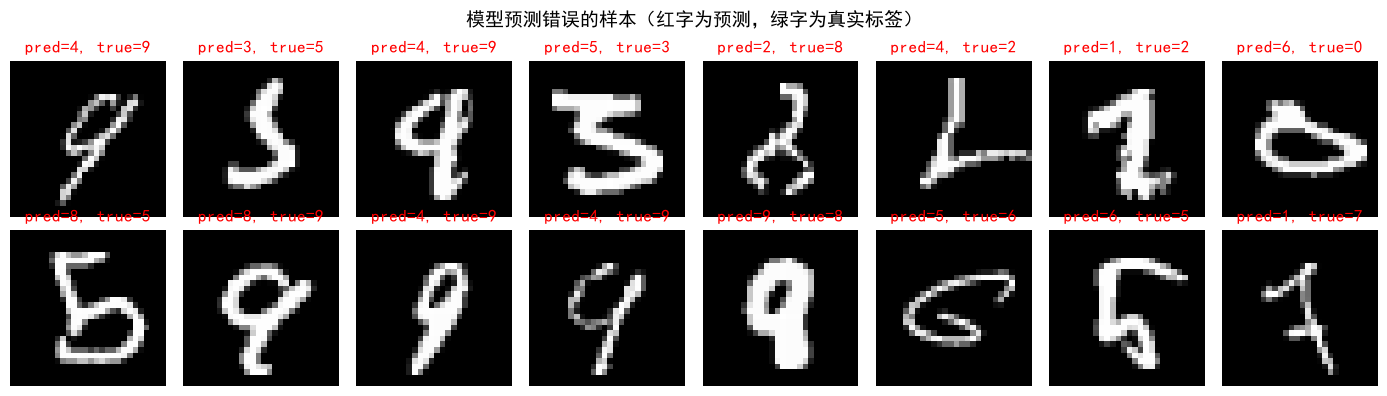

[观察] 模型在测试集上犯的错，很多其实是人眼也难区分的模糊手写体。


In [10]:
# 1.6 错误案例分析：看看模型在哪些样本上犯了错
model.eval()
wrong_images = []
wrong_preds = []
wrong_labels = []

# 从测试集中收集前 16 个错误样本
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        pred = output.argmax(dim=1)
        mask = pred != target
        wrong_images.extend(data[mask].cpu())
        wrong_preds.extend(pred[mask].cpu().tolist())
        wrong_labels.extend(target[mask].cpu().tolist())
        if len(wrong_images) >= 16:
            break

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle("模型预测错误的样本（红字为预测，绿字为真实标签）", fontsize=14)

for ax, img, pred, label in zip(axes.flat, wrong_images[:16], wrong_preds[:16], wrong_labels[:16]):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"pred={pred}, true={label}", color='red' if pred != label else 'green')
    ax.axis('off')

plt.tight_layout()
plt.savefig("./outputs/mnist_wrong_cases.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"[观察] 模型在测试集上犯的错，很多其实是人眼也难区分的模糊手写体。")

## 2. Demo 2：YOLOv8 目标检测推理

### 一句话直觉
给一张图片，模型自动告诉你"图里有什么物体、它们在什么位置"。

### 对应课程路线
**L4 计算机视觉 → 目标检测**。

### 本 Demo 会展示什么
1. 原始图片长什么样。
2. YOLOv8n 模型信息和参数量。
3. 推理结果：检测框、类别、置信度。
4. 可视化：在原图上画出检测框。
5. 中间信息：每个检测框的具体坐标和概率。

### 观察重点
- 一次前向传播同时完成"定位"和"分类"。
- 置信度表示模型对预测结果有多确定。
- YOLO 是工业界最常用的实时检测器之一。

[使用本地图片] ./data/sample_images/zidane.jpg
  图片尺寸: (1280, 720) (宽 x 高)
  图片模式: RGB


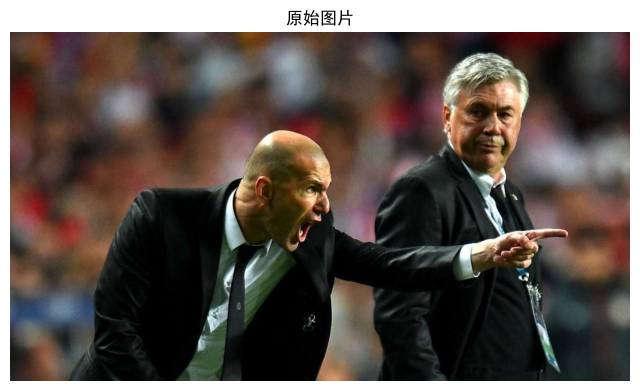

In [6]:
# 2.1 准备示例图片
import urllib.request
from pathlib import Path
from PIL import Image

# 使用 YOLOv8 官方示例图（足球运动员）
image_url = "https://ultralytics.com/images/zidane.jpg"
image_path = "./data/sample_images/zidane.jpg"

if not Path(image_path).exists():
    print("[下载中] YOLO 示例图片...")
    urllib.request.urlretrieve(image_url, image_path)
    print(f"[完成] 保存至 {image_path}")
else:
    print(f"[使用本地图片] {image_path}")

# 显示原始图片
img = Image.open(image_path).convert("RGB")
print(f"  图片尺寸: {img.size} (宽 x 高)")
print(f"  图片模式: {img.mode}")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title("原始图片")
plt.axis('off')
plt.savefig("./outputs/yolo_input.jpg", dpi=120, bbox_inches='tight')
plt.show()

In [12]:
# 2.2 加载 YOLOv8n 模型并查看信息
from ultralytics import YOLO

print("[加载中] YOLOv8n 模型（首次会自动下载，约 6MB）...")
model = YOLO("yolov8n.pt")

# YOLO 模型对象没有直接的参数量属性，我们估算一下
# 这里用简单方式展示模型任务类型
print(f"  模型任务类型: {model.task}")
print(f"  模型名称: {model.model.names}")
print(f"  可检测类别数: {len(model.model.names)}")
print(f"  部分类别示例: {list(model.model.names.values())[:10]}")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\nan\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[加载中] YOLOv8n 模型（首次会自动下载，约 6MB）...
  模型任务类型: detect
  模型名称: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41:

[推理中] 对图片执行目标检测...

检测结果（中间信息）:
  检测到物体数量: 3
--------------------------------------------------
  [1] 类别: person       | 置信度: 0.8357 | 边框: ( 114.8,  197.4, 1114.5,  711.9)
  [2] 类别: person       | 置信度: 0.8190 | 边框: ( 748.5,   41.9, 1143.1,  713.0)
  [3] 类别: tie          | 置信度: 0.2910 | 边框: ( 439.5,  437.1,  524.4,  709.1)


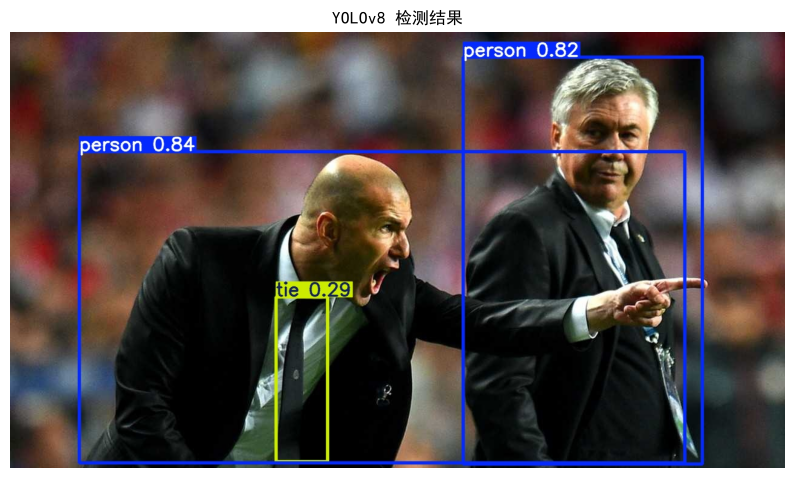


[保存] 检测结果 -> ./outputs/yolo_result.jpg


In [13]:
# 2.3 执行目标检测推理
print("[推理中] 对图片执行目标检测...")
results = model(image_path, verbose=False)
result = results[0]

# 打印检测到的每个物体的详细信息
print("\n检测结果（中间信息）:")
print(f"  检测到物体数量: {len(result.boxes) if result.boxes is not None else 0}")
print("-" * 50)

if result.boxes is not None:
    names = result.names
    for i, box in enumerate(result.boxes):
        cls_id = int(box.cls.item())
        conf = float(box.conf.item())
        # xyxy 格式：[左上角 x, 左上角 y, 右下角 x, 右下角 y]
        x1, y1, x2, y2 = box.xyxy[0].cpu().tolist()
        label = names[cls_id]
        print(f"  [{i+1}] 类别: {label:12s} | 置信度: {conf:.4f} | "
              f"边框: ({x1:6.1f}, {y1:6.1f}, {x2:6.1f}, {y2:6.1f})")
else:
    print("  未检测到任何物体")

# 保存并显示带检测框的结果
os.makedirs("./outputs", exist_ok=True)
result.save(filename="./outputs/yolo_result.jpg")

result_img = Image.open("./outputs/yolo_result.jpg")
plt.figure(figsize=(10, 8))
plt.imshow(result_img)
plt.title("YOLOv8 检测结果")
plt.axis('off')
plt.show()
print("\n[保存] 检测结果 -> ./outputs/yolo_result.jpg")

## 3. Demo 3：GPT-2 文本生成推理

### 一句话直觉
模型根据已经生成的文字，不断预测"下一个最可能出现的词"，从而续写出一段文字。

### 对应课程路线
**L5 NLP/LLM → 预训练语言模型 / Decoder-only 架构**。

### 本 Demo 会展示什么
1. GPT-2 模型基本信息和参数量。
2. 给定 prompt 后，模型如何逐 token 生成文本。
3. 每次生成结果可能不同（因为采用了采样策略）。
4. 打印生成过程的中间 token。

### 观察重点
- GPT-2 是 Decoder-only 模型，只能看已生成的词，不能看未来的词。
- 生成时使用 `do_sample=True`，每次结果有随机性。
- "next token prediction" 是几乎所有现代 LLM 的核心。

In [14]:
# 3.1 加载 GPT-2 模型和分词器
from transformers import GPT2LMHeadModel, GPT2Tokenizer

print("[加载中] GPT-2 模型和分词器（首次会自动下载，约 500MB）...")
model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model_gpt2 = GPT2LMHeadModel.from_pretrained(model_name).to(device)
model_gpt2.eval()

# 打印模型规模
total_params = sum(p.numel() for p in model_gpt2.parameters())
print(f"  模型参数量: {total_params / 1e6:.0f}M")
print(f"  词表大小: {len(tokenizer)}")
print(f"  特殊 token: {tokenizer.special_tokens_map}")

[加载中] GPT-2 模型和分词器（首次会自动下载，约 500MB）...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

  模型参数量: 124M
  词表大小: 50257
  特殊 token: {'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>'}


In [15]:
# 3.2 文本生成
prompt = "Deep learning is a branch of machine learning that"
print(f'Prompt: "{prompt}"')

# 编码 prompt：把文本转成模型能理解的 token id 序列
inputs = tokenizer(prompt, return_tensors="pt").to(device)
print("Prompt 的 token 化结果:")
print(f"  token ids: {inputs['input_ids'][0].tolist()}")
print(f"  tokens: {tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].tolist())}")
print(f"  长度: {inputs['input_ids'].shape[1]} tokens")

# 生成参数说明：
# - max_new_tokens: 新生成多少个 token
# - do_sample: 是否采样（True 则有随机性）
# - top_k/top_p: 控制采样范围，避免生成太离谱的内容
# - temperature: 温度越高，生成越随机；越低越保守
with torch.no_grad():
    outputs = model_gpt2.generate(
        **inputs,
        max_new_tokens=60,
        num_return_sequences=1,
        do_sample=True,
        top_k=50,
        top_p=0.95,
        temperature=0.8,
        pad_token_id=tokenizer.eos_token_id,
    )

generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print("生成结果:")
print("-" * 60)
print(generated_text)
print("-" * 60)

# 单独显示新生成的部分
new_text = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
print()
print("[新增内容]", new_text)


Prompt: "Deep learning is a branch of machine learning that"
Prompt 的 token 化结果:
  token ids: [29744, 4673, 318, 257, 8478, 286, 4572, 4673, 326]
  tokens: ['Deep', 'Ġlearning', 'Ġis', 'Ġa', 'Ġbranch', 'Ġof', 'Ġmachine', 'Ġlearning', 'Ġthat']
  长度: 9 tokens
生成结果:
------------------------------------------------------------
Deep learning is a branch of machine learning that uses statistical techniques to learn a large set of problems. The algorithm does not necessarily provide a fully accurate picture of what you want to do in a particular problem, so it is usually only a partial measure of the overall processing power of the algorithm. It is commonly called a latent learning algorithm because it is
------------------------------------------------------------

[新增内容]  uses statistical techniques to learn a large set of problems. The algorithm does not necessarily provide a fully accurate picture of what you want to do in a particular problem, so it is usually only a partial measure of t

In [16]:
# 3.3 多次采样：观察生成的随机性
print("同样的 prompt 生成 3 次，观察结果的差异：\n")
for i in range(3):
    with torch.no_grad():
        outputs = model_gpt2.generate(
            **inputs,
            max_new_tokens=40,
            do_sample=True,
            top_k=50,
            top_p=0.95,
            temperature=0.9,
            pad_token_id=tokenizer.eos_token_id,
        )
    text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"第 {i+1} 次: {text[len(prompt):].strip()}\n")

同样的 prompt 生成 3 次，观察结果的差异：

第 1 次: includes a few algorithms and a number of sub-programs. When machine learning is performed, the algorithm searches for a set of patterns on a tree that is larger than the current tree of available matches

第 2 次: takes the idea of neural networks, which means that we can build on existing models to build models of what is the human mind.

"Imagine the human mind being in the presence of the artificial

第 3 次: is used for solving complex problems. While these methods can be used for complex problems, we expect it to be easier to use in non-technical ways.

You are working with a computer that



## 4. Demo 4：CLIP 零样本图像分类

### 一句话直觉
不需要针对特定任务训练，只要告诉模型"这张图可能是猫、狗、车..."，模型就能判断图片最像哪个描述。

### 对应课程路线
**L6 多模态 → 视觉-语言模型**。

### 本 Demo 会展示什么
1. 示例图片及其真实内容。
2. CLIP 模型如何把图片和文本映射到同一语义空间。
3. 每个候选类别的相似度分数和概率。
4. 用条形图可视化分类概率。

### 观察重点
- 正确类别的概率应该明显高于其他类别。
- CLIP 的关键思想是"对比学习"：拉近匹配的图文对，推开不匹配的。
- Stable Diffusion 等文生图模型也使用了 CLIP 的文本编码器。

[使用本地图片] ./data/sample_images/cat.jpg
  图片尺寸: (300, 225)


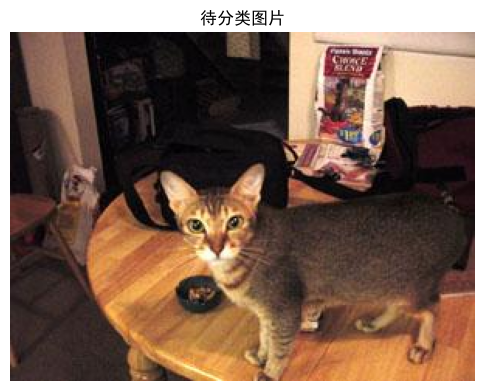

In [7]:
# 4.1 准备图片
from torchvision import datasets
from PIL import Image

cat_path = "./data/sample_images/cat.jpg"

if not Path(cat_path).exists():
    print("[下载中] 从 Oxford-IIIT Pet 取一张 cat 图片...")
    pet = datasets.OxfordIIITPet(root="./data", split="test", download=True)

    # 前 12 个类别是猫品种，后面是狗品种
    cat_idx = [i for i, (_, label) in enumerate(pet) if label < 12][0]

    image, _ = pet[cat_idx]
    image.save(cat_path)
    print(f"[完成] 保存至 {cat_path}")
else:
    print(f"[使用本地图片] {cat_path}")

image = Image.open(cat_path).convert("RGB")
print(f"  图片尺寸: {image.size}")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("待分类图片")
plt.axis('off')
plt.savefig("./outputs/clip_input.jpg", dpi=120, bbox_inches='tight')
plt.show()

In [8]:
# 4.2 定义候选类别并加载 CLIP
candidate_labels = [
    "a photo of a cat",
    "a photo of a dog",
    "a photo of a car",
    "a photo of a bird",
    "a photo of a person",
]
print("候选类别:")
for label in candidate_labels:
    print(f"  - {label}")

from transformers import CLIPProcessor, CLIPModel

print("\n[加载中] CLIP 模型（首次会自动下载，约 340MB）...")
clip_name = "openai/clip-vit-base-patch32"
clip_processor = CLIPProcessor.from_pretrained(clip_name)
clip_model = CLIPModel.from_pretrained(clip_name).to(device)
clip_model.eval()
print("  CLIP 模型加载完成")

候选类别:
  - a photo of a cat
  - a photo of a dog
  - a photo of a car
  - a photo of a bird
  - a photo of a person

[加载中] CLIP 模型（首次会自动下载，约 340MB）...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  CLIP 模型加载完成



CLIP 分类结果:
------------------------------------------------------------
  cat        | 相似度分数:   25.723 | 概率: 98.40%
  person     | 相似度分数:   21.341 | 概率: 1.23%
  dog        | 相似度分数:   19.945 | 概率: 0.30%
  car        | 相似度分数:   17.826 | 概率: 0.04%
  bird       | 相似度分数:   17.746 | 概率: 0.03%

[预测结果] 最可能的类别: cat


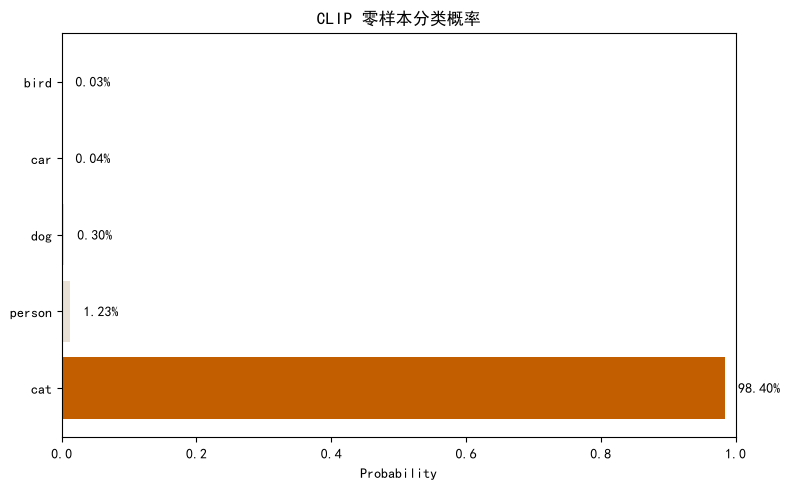

[保存] 分类概率图 -> ./outputs/clip_probability.png


In [9]:
# 4.3 计算图文相似度并可视化
# processor 会同时处理图片和文本，把它们转成模型需要的格式
inputs = clip_processor(
    text=candidate_labels,
    images=image,
    return_tensors="pt",
    padding=True
).to(device)

with torch.no_grad():
    outputs = clip_model(**inputs)
    logits_per_image = outputs.logits_per_image  # 图片对每个文本的相似度分数
    probs = logits_per_image.softmax(dim=1)      # 转成概率分布

# 打印每个类别的相似度和概率
print("\nCLIP 分类结果:")
print("-" * 60)
prob_list = probs[0].cpu().tolist()
logit_list = logits_per_image[0].cpu().tolist()
results = sorted(
    zip(candidate_labels, prob_list, logit_list),
    key=lambda x: x[1],
    reverse=True
)
for label, prob, logit in results:
    short = label.replace("a photo of a ", "")
    print(f"  {short:10s} | 相似度分数: {logit:8.3f} | 概率: {prob:.2%}")

best_label = results[0][0].replace("a photo of a ", "")
print(f"\n[预测结果] 最可能的类别: {best_label}")

# 条形图可视化
fig, ax = plt.subplots(figsize=(8, 5))
labels = [r[0].replace("a photo of a ", "") for r in results]
values = [r[1] for r in results]
colors = ['#c25e00' if v == max(values) else '#e8e0d5' for v in values]

bars = ax.barh(labels, values, color=colors)
ax.set_xlabel('Probability')
ax.set_title('CLIP 零样本分类概率')
ax.set_xlim(0, 1)

# 在条形上标注数值
for bar, val in zip(bars, values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.2%}", va='center', fontsize=10)

plt.tight_layout()
plt.savefig("./outputs/clip_probability.png", dpi=120, bbox_inches='tight')
plt.show()
print("[保存] 分类概率图 -> ./outputs/clip_probability.png")

## 5. 小结

这节课我们通过 4 个 Demo，亲手摸到了深度学习的几个核心方向：

| Demo | 方向 | 路线位置 | 关键直觉 |
|------|------|----------|----------|
| MNIST 训练 | CV 基础 | L3 深度学习核心 | 模型通过 loss 下降、acc 上升学习 |
| YOLOv8 检测 | CV 应用 | L4 计算机视觉 | 一次前向出框+类别 |
| GPT-2 生成 | NLP/LLM | L5 自然语言处理 | 自回归猜下一个词 |
| CLIP 分类 | 多模态 | L6 多模态 | 图文在同一空间比相似度 |

## 课后建议

1. 修改 `candidate_labels` 里的文本描述，看看 CLIP 对同一张图会给出什么不同结果。
2. 换一张自己的照片跑 YOLO，观察检测效果。
3. 尝试把 MNIST 的 `num_epochs` 改成 5，观察准确率能到多少。
4. 给 GPT-2 换一个中文 prompt（注意 GPT-2 是英文模型，中文效果有限）。

## 下节课预告

第 2 节：从感知机到 CNN —— 手写 NumPy 感知机，再用 PyTorch 训练 MLP，最后在 MNIST 上跑出 95%+。
